# Libraries

In [177]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [178]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\Na2SO4\20240508 - Ag60 GDE_0.3 M Na2SO4_pH1

10-Aug-26  07:18 PM    <DIR>          .
07-Jun-26  07:17 PM    <DIR>          ..
06-Jun-26  06:34 PM    <DIR>          .ipynb_checkpoints
03-Jun-26  07:26 AM            15,127 03M_pH1_FE_H2_CO_stacked bar.png
03-Aug-26  02:31 PM           373,124 0p3M_pH1 Na2SO4_20240513_0701_1min - Copy.xlsx
04-Aug-26  07:17 AM            71,768 0p3M_pH1 Na2SO4_20240513_0701_1min.xlsx
13-May-24  09:01 AM         1,561,876 0p3M_pH1 Na2SO4_20240513_0701_Line_1.csv
06-Jun-26  05:47 PM           689,241 20240508 - Ag60 GDE_0.3 M Na2SO4_pH1.ipynb
10-Aug-26  07:15 PM           679,887 20240508 - Ag60 GDE_0.3 M Na2SO4_pH1_CORRECTED.ipynb
10-Aug-26  07:13 PM               588 20240508_0.3 M Na2SO4_pH1_Energy Consumption.csv
10-Aug-26  07:14 PM             5,182 20240508_0.3M Na2SO4_pH1.csv
10-Aug-26  07:12 PM             1,400

# Load Data

In [179]:
Book = "Book_20240508 - Ag60 GDE_0.3 M Na2SO4_pH1_repeated.xlsx"
Book = pd.read_excel(Book)
Book.tail(10)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
26,Ag60 GDE in PTFE holder,60,73.387626,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.1,2024-05-09 01:15:00,12.350000,15.518002,...,0.150046,0.046841,0.802045,0.000500,0.694003,0.146766,NaN,0.840769,0.055180,NaN
27,Ag60 GDE in PTFE holder,60,74.095792,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.1,2024-05-09 01:51:00,12.950000,16.098397,...,0.155519,0.045031,0.798362,0.000508,0.726254,0.142456,NaN,0.868710,0.053393,87.303332
28,Ag60 GDE in PTFE holder,60,73.644803,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.1,2024-05-09 02:17:00,13.383333,16.380156,...,0.158367,0.042167,0.798397,0.000507,0.735056,0.132583,NaN,0.867639,0.050165,NaN
29,Ag60 GDE in PTFE holder,60,72.930140,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-2.1,2024-05-09 02:51:00,13.950000,16.734063,...,0.161878,0.038695,0.798346,0.000500,0.744061,0.120484,NaN,0.864545,0.046228,86.528518
30,Ag60 GDE in PTFE holder,60,82.496581,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-09 03:16:00,14.366667,22.632131,...,0.218749,0.048332,0.731610,0.000752,0.770466,1.055446,NaN,1.825911,0.061969,NaN
31,Ag60 GDE in PTFE holder,60,81.284627,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-09 03:52:00,14.966667,23.472780,...,0.226804,0.044061,0.727830,0.000744,0.787101,0.948032,NaN,1.735133,0.057082,79.885650
32,Ag60 GDE in PTFE holder,60,82.534969,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-09 04:18:00,15.400000,23.878932,...,0.230620,0.041807,0.726272,0.000729,0.812654,0.147320,NaN,0.959974,0.054431,NaN
33,Ag60 GDE in PTFE holder,60,81.848779,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-09 04:52:00,15.966667,24.286356,...,0.234619,0.038006,0.726088,0.000719,0.819870,0.132813,NaN,0.952683,0.049740,79.094647
34,Ag60 GDE in PTFE holder,60,69.318439,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-09 05:17:00,16.383333,15.498535,...,0.149953,0.017075,0.832007,0.000366,2.751475,0.313314,NaN,3.064789,0.020110,NaN
35,Ag60 GDE in PTFE holder,60,70.973785,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-09 05:53:00,16.983333,15.015938,...,0.145320,0.015070,0.838667,0.000347,2.730142,0.283115,NaN,3.013256,0.017651,88.216795


In [180]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
33,Ag60 GDE in PTFE holder,60,81.85,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-05-09 04:52:00,15.97,24.286356,...,0.038006,0.726088,0.000719,0.819870,0.132813,NaN,0.952683,0.049740,79.094647,81.85
34,Ag60 GDE in PTFE holder,60,69.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-09 05:17:00,16.38,15.498535,...,0.017075,0.832007,0.000366,2.751475,0.313314,NaN,3.064789,0.020110,NaN,69.32
35,Ag60 GDE in PTFE holder,60,70.97,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-05-09 05:53:00,16.98,15.015938,...,0.015070,0.838667,0.000347,2.730142,0.283115,NaN,3.013256,0.017651,88.216795,70.97


### Temp from pH meter

In [181]:
Temp = "2024-05-13_093306.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 23.037820112429728
Temp C median: 23.1


## Power Supply

In [182]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.tail(5)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time,Unnamed: 13,Time_minute,Unnamed: 15,Unnamed: 16
11508,40.00V,9.84V,3.000A,3.004A,320.00W,29.57W,NaN,NaN,NaN,On,CC,NaN,09-05-24 4:53,NaN,NaN,NaN,NaN
11509,40.00V,9.96V,3.000A,3.005A,320.00W,29.93W,NaN,NaN,NaN,On,CC,NaN,09-05-24 4:53,NaN,NaN,NaN,NaN
11510,40.00V,10.14V,3.000A,3.001A,320.00W,30.44W,NaN,NaN,NaN,On,CC,NaN,09-05-24 4:54,NaN,NaN,NaN,NaN
11511,40.00V,10.17V,3.000A,3.007A,320.00W,30.59W,NaN,NaN,NaN,On,CC,NaN,09-05-24 4:54,NaN,NaN,NaN,NaN
11512,40.00V,9.78V,3.000A,3.006A,320.00W,29.41W,NaN,NaN,NaN,On,CC,NaN,09-05-24 4:54,NaN,NaN,NaN,NaN


In [183]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.31V
0.100A 1    2.93V
       2    2.94V

In [184]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d-%m-%y %H:%M"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-05-08 12:00:00     0.124      2.98
1 2024-05-08 14:00:00     0.270      3.22
2 2024-05-08 16:00:00     0.517      4.00
3 2024-05-08 18:00:00     0.771      5.01
4 2024-05-08 20:00:00     1.020      6.06
5 2024-05-08 22:00:00     1.515      7.44
6 2024-05-09 00:00:00     2.020      8.63
7 2024-05-09 02:00:00     3.016     10.69
8 2024-05-09 04:00:00     3.015     10.71


In [185]:
# cell_voltage = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-08 12:00:00     0.124      2.98
1 2024-05-08 14:00:00     0.270      3.22
2 2024-05-08 16:00:00     0.517      4.00
3 2024-05-08 18:00:00     0.771      5.01
4 2024-05-08 20:00:00     1.020      6.06
5 2024-05-08 22:00:00     1.515      7.44
6 2024-05-09 00:00:00     2.020      8.63
7 2024-05-09 02:00:00     3.016     10.69


In [186]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [187]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.124,2.98
0.270,3.22
0.517,4.00
0.771,5.01
1.020,6.06
1.515,7.44
2.020,8.63
3.016,10.69


In [188]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.124,2.98,1.24
0.270,3.22,2.70
0.517,4.00,5.17
0.771,5.01,7.71
1.020,6.06,10.20
1.515,7.44,15.15
2.020,8.63,20.20
3.016,10.69,30.16


## Flow rate

In [189]:
flow_rate = "0p3M_pH1 Na2SO4_20240513_0701_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-13 07:01:19.430000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p3M_pH1 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [190]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})
flow_rate.head(10)

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-08 11:01:59.981000,52.536734,26.268367
1,2024-05-08 11:03:00.029000,52.803405,26.401703
2,2024-05-08 11:03:59.990000,52.757035,26.378518
3,2024-05-08 11:05:00.038000,52.762065,26.381033
4,2024-05-08 11:06:00,52.535606,26.267803
5,2024-05-08 11:06:59.962000,52.210048,26.105024
6,2024-05-08 11:08:00.010000,52.007025,26.003512
7,2024-05-08 11:08:59.971000,52.445348,26.222674
8,2024-05-08 11:10:00.019000,52.444689,26.222345
9,2024-05-08 11:10:59.981000,52.591384,26.295692


In [191]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-08 10:00:00     52.007025     56.475498       53.94318   
1 2024-05-08 12:00:00     55.778093     62.161074      59.173915   
2 2024-05-08 14:00:00     60.207807     65.864998      62.797351   
3 2024-05-08 16:00:00      63.25429     68.492372       65.96727   
4 2024-05-08 18:00:00     65.705331     69.195943      67.501268   
5 2024-05-08 20:00:00     66.289349     71.903792      68.906263   
6 2024-05-08 22:00:00     68.592007     75.423203       71.96519   
7 2024-05-09 00:00:00     72.250484     83.894493      78.204698   
8 2024-05-09 02:00:00     67.644207     82.623487      75.360888   

  Flow_rate_median  
0        53.775165  
1        59.863402  
2        63.397182  
3        66.444242  
4        67.552797  
5        68.947625  
6        72.656913  
7        81.193197  
8        70.241824  


#### Correction dry flow

In [192]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.308 L/mol
p_sat = 2.8269 kPa -> x(H2O) = 2.79 % -> dry factor 0.97210


In [193]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [194]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-08 10:00:00,52.007025,56.475498,53.94318,53.775165,50.556064,54.899869,52.438201,52.274874,0.124,2.98
1,2024-05-08 12:00:00,55.778093,62.161074,59.173915,59.863402,54.221921,60.426821,57.523002,58.193253,0.270,3.22
2,2024-05-08 14:00:00,60.207807,65.864998,62.797351,63.397182,58.528049,64.027408,61.045346,61.628443,0.517,4.00
3,2024-05-08 16:00:00,63.25429,68.492372,65.96727,66.444242,61.489537,66.58148,64.126827,64.590491,0.771,5.01
4,2024-05-08 18:00:00,65.705331,69.195943,67.501268,67.552797,63.872196,67.265422,65.618027,65.668119,1.020,6.06
5,2024-05-08 20:00:00,66.289349,71.903792,68.906263,68.947625,64.43992,69.897724,66.983824,67.024032,1.515,7.44
6,2024-05-08 22:00:00,68.592007,75.423203,71.96519,72.656913,66.678336,73.318946,69.95741,70.629833,2.020,8.63
7,2024-05-09 00:00:00,72.250484,83.894493,78.204698,81.193197,70.234744,81.553892,76.022839,78.927961,3.016,10.69


In [197]:
# dfflow_rate.to_csv('20240508_0.3M Na2SO4_pH1_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] 
 <!-- * area of the electrode [m2] -->

In [198]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.124,2.98,1.24,124.0
0.270,3.22,2.70,270.0
0.517,4.00,5.17,517.0


In [199]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.124,2.98,1.24,124.0,2660.544
0.270,3.22,2.70,270.0,6259.680
0.517,4.00,5.17,517.0,14889.600
0.771,5.01,7.71,771.0,27811.512
1.020,6.06,10.20,1020.0,44504.640
1.515,7.44,15.15,1515.0,81155.520
2.020,8.63,20.20,2020.0,125514.720
3.016,10.69,30.16,3016.0,232135.488


In [200]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.124,2.98,1.24,124.0,2660.544,0.000739
0.270,3.22,2.70,270.0,6259.680,0.001739
0.517,4.00,5.17,517.0,14889.600,0.004136
0.771,5.01,7.71,771.0,27811.512,0.007725
1.020,6.06,10.20,1020.0,44504.640,0.012362
1.515,7.44,15.15,1515.0,81155.520,0.022543
2.020,8.63,20.20,2020.0,125514.720,0.034865
3.016,10.69,30.16,3016.0,232135.488,0.064482


In [203]:
# dfcell_voltage.to_csv('20240508_0.3 M Na2SO4_pH1_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [204]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-08 12:54:00,0.00,0.000000,...,0.000000,0.043312,0.000000,0.000000,NaN,NaN,NaN,NaN,0.00,0.0
1,Ag60 GDE in PTFE holder,60,52.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 13:07:00,0.22,1.064854,...,0.789747,0.041104,0.537162,0.000000,NaN,0.537162,0.000000,83.217708,52.21,0.0
2,Ag60 GDE in PTFE holder,60,53.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 13:34:00,0.67,1.836719,...,0.972373,0.002623,0.967257,0.000000,NaN,0.967257,0.000000,NaN,53.76,0.0
3,Ag60 GDE in PTFE holder,60,56.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 14:00:00,1.10,1.797115,...,0.979451,0.001115,0.988275,0.000000,NaN,0.988275,0.000000,101.583306,56.02,1.0
4,Ag60 GDE in PTFE holder,60,58.36,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 14:25:00,1.52,1.746399,...,0.980688,0.000854,1.001762,0.000000,NaN,1.001762,0.000000,NaN,58.36,1.0
5,Ag60 GDE in PTFE holder,60,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 14:51:00,1.95,1.724132,...,0.981221,0.000720,0.984420,0.000000,NaN,0.984420,0.000000,101.844139,58.21,1.0
6,Ag60 GDE in PTFE holder,60,60.86,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 15:16:00,2.37,3.325321,...,0.966482,0.000519,1.025447,0.000000,NaN,1.025447,0.000000,NaN,60.86,2.0
7,Ag60 GDE in PTFE holder,60,60.13,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 15:42:00,2.80,3.441477,...,0.965822,0.000403,1.046514,0.000000,NaN,1.046514,0.000000,100.310384,60.13,2.0
8,Ag60 GDE in PTFE holder,60,60.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 16:18:00,3.40,3.428803,...,0.966094,0.000331,1.044774,0.000000,NaN,1.044774,0.000000,NaN,60.21,3.0
9,Ag60 GDE in PTFE holder,60,61.38,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 16:52:00,3.97,3.413701,...,0.966324,0.000309,1.059486,0.000000,NaN,1.059486,0.000000,100.367009,61.38,3.0


## Current Density

In [205]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,0.00,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-05-08 12:54:00,0.00,0.000000,...,0.043312,0.000000,0.000000,NaN,NaN,NaN,NaN,0.00,0.0,0.0
1,Ag60 GDE in PTFE holder,60,52.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 13:07:00,0.22,1.064854,...,0.041104,0.537162,0.000000,NaN,0.537162,0.000000,83.217708,52.21,0.0,-130.0
2,Ag60 GDE in PTFE holder,60,53.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 13:34:00,0.67,1.836719,...,0.002623,0.967257,0.000000,NaN,0.967257,0.000000,NaN,53.76,0.0,-130.0
3,Ag60 GDE in PTFE holder,60,56.02,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 14:00:00,1.10,1.797115,...,0.001115,0.988275,0.000000,NaN,0.988275,0.000000,101.583306,56.02,1.0,-130.0
4,Ag60 GDE in PTFE holder,60,58.36,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 14:25:00,1.52,1.746399,...,0.000854,1.001762,0.000000,NaN,1.001762,0.000000,NaN,58.36,1.0,-130.0
5,Ag60 GDE in PTFE holder,60,58.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.130,2024-05-08 14:51:00,1.95,1.724132,...,0.000720,0.984420,0.000000,NaN,0.984420,0.000000,101.844139,58.21,1.0,-130.0
6,Ag60 GDE in PTFE holder,60,60.86,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 15:16:00,2.37,3.325321,...,0.000519,1.025447,0.000000,NaN,1.025447,0.000000,NaN,60.86,2.0,-252.0
7,Ag60 GDE in PTFE holder,60,60.13,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 15:42:00,2.80,3.441477,...,0.000403,1.046514,0.000000,NaN,1.046514,0.000000,100.310384,60.13,2.0,-252.0
8,Ag60 GDE in PTFE holder,60,60.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 16:18:00,3.40,3.428803,...,0.000331,1.044774,0.000000,NaN,1.044774,0.000000,NaN,60.21,3.0,-252.0
9,Ag60 GDE in PTFE holder,60,61.38,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.252,2024-05-08 16:52:00,3.97,3.413701,...,0.000309,1.059486,0.000000,NaN,1.059486,0.000000,100.367009,61.38,3.0,-252.0


In [206]:
# Book[["area(H2)", "area(CO)", "c(H2)", "c(CO)"]].head(25)

## FE(CO)

In [207]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [208]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.308 L/mol


In [209]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.124, 0.27, 0.517, 0.771, 1.02, 1.515, 2.02, 3.016]

In [210]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[6, 4, 3, 5, 4, 4, 4, 4]

In [211]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

,c(H2),c(CO),FE(H2),FE(CO)
0,0.000000,0.000000,0.000000,0.000000
1,0.010106,0.000000,0.537162,0.000000
2,0.017672,0.000000,0.967257,0.000000
3,0.017328,0.000000,0.988275,0.000000
4,0.016860,0.000000,1.001762,0.000000
5,0.016611,0.000000,0.984420,0.000000
6,0.032080,0.000000,1.025447,0.000000
7,0.033136,0.000000,1.046514,0.000000
8,0.033040,0.000000,1.044774,0.000000
9,0.032867,0.000000,1.059486,0.000000


In [212]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 98.6 / 88.9 %


### Mean FE per current density

In [213]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        124   73.045689    0.000000     93.345938      0.000000  15.966087   
1        270   93.478799    0.000000     93.971158      0.000000   0.684385   
2        517   92.797633    0.000000     93.554912      0.000000   0.830273   
3        771   87.935941    1.187776     91.850038      1.400596   4.273079   
4       1020   80.140729   13.747350     80.199528     13.758281   0.563520   
5       1515   68.147937   23.586037     68.390835     23.828212   1.317379   
6       2020   72.377963   19.977600     72.604767     20.169879   1.156660   
7       3016   78.839858   14.906535     79.191009     14.865801   1.171238   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   0.000000  39.108766   0.000000  65.438069  ...   0.013096     0.016735  6   
1   0.000000   1.368769   0.000000  93.163724  ...   0.032781     0.032953  4   
2   0.000000   1.438075   0.000000  92.347040

## FE(H2)

In [214]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

0      0.000000
1     56.366433
2     98.567465
3     96.648361
4     94.038899
5     92.652976
6     91.481586
7     94.491296
8     94.217879
9     93.724437
10    91.139167
11    93.554912
12    93.698821
13    93.668533
14    91.850038
15    92.271744
16    90.955864
17    70.933525
18    78.707360
19    80.104828
20    80.294229
21    81.456501
22    69.180701
23    64.795210
24    67.600969
25    71.014869
26    69.414353
27    71.945842
28    73.263691
29    74.887968
30    78.530418
31    79.851600
32    75.741380
33    81.236033
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

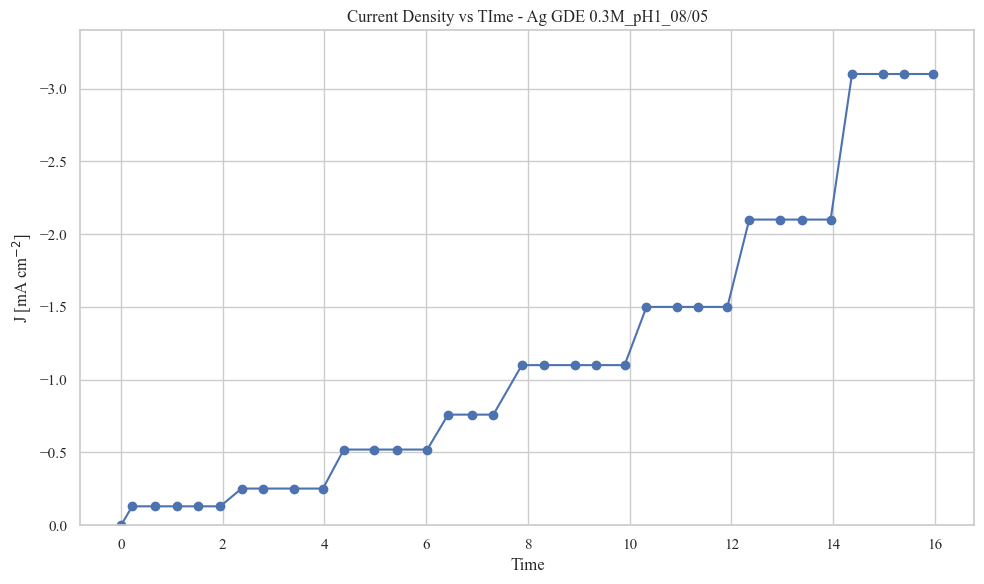

In [215]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Applied current / A'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3.4)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

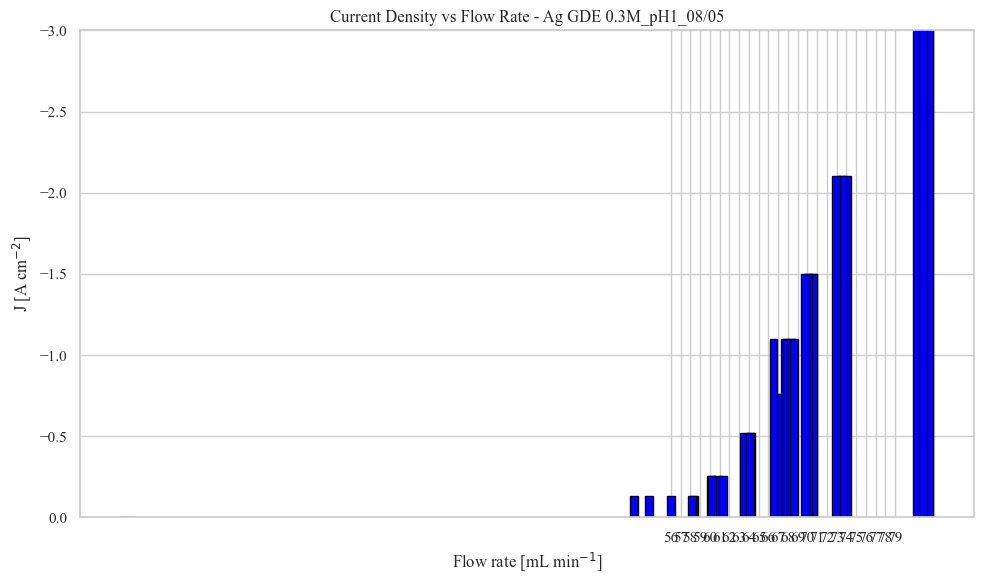

In [216]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


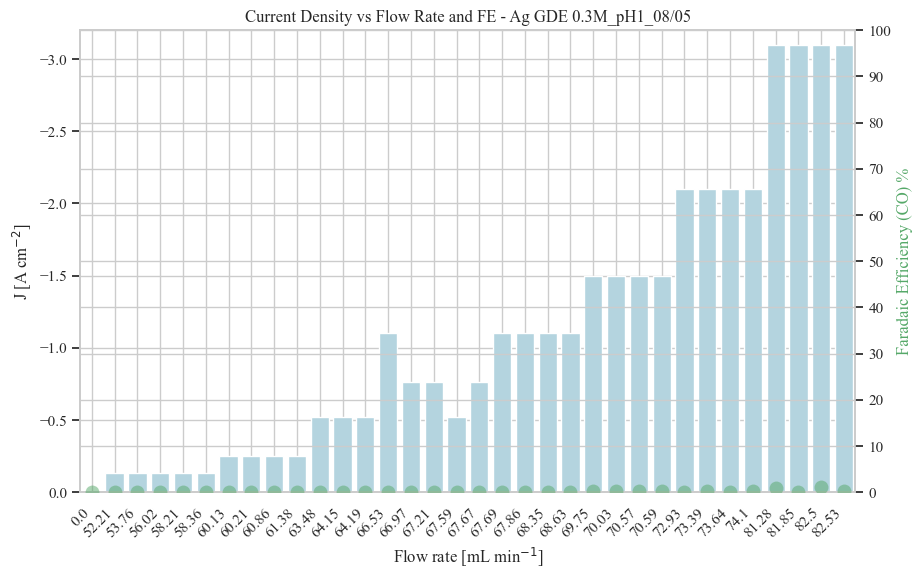

In [217]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH1_08/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [218]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [219]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\Na2SO4\20240508 - Ag60 GDE_0.3 M Na2SO4_pH1

11-Aug-26  08:11 AM    <DIR>          .
07-Jun-26  07:17 PM    <DIR>          ..
06-Jun-26  06:34 PM    <DIR>          .ipynb_checkpoints
03-Jun-26  07:26 AM            15,127 03M_pH1_FE_H2_CO_stacked bar.png
03-Aug-26  02:31 PM           373,124 0p3M_pH1 Na2SO4_20240513_0701_1min - Copy.xlsx
04-Aug-26  07:17 AM            71,768 0p3M_pH1 Na2SO4_20240513_0701_1min.xlsx
13-May-24  09:01 AM         1,561,876 0p3M_pH1 Na2SO4_20240513_0701_Line_1.csv
06-Jun-26  05:47 PM           689,241 20240508 - Ag60 GDE_0.3 M Na2SO4_pH1.ipynb
11-Aug-26  08:11 AM           695,552 20240508 - Ag60 GDE_0.3 M Na2SO4_pH1_CORRECTED.ipynb
11-Aug-26  08:11 AM               588 20240508_0.3 M Na2SO4_pH1_Energy Consumption.csv
10-Aug-26  07:14 PM             5,182 20240508_0.3M Na2SO4_pH1.csv
11-Aug-26  08:11 AM             1,400

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


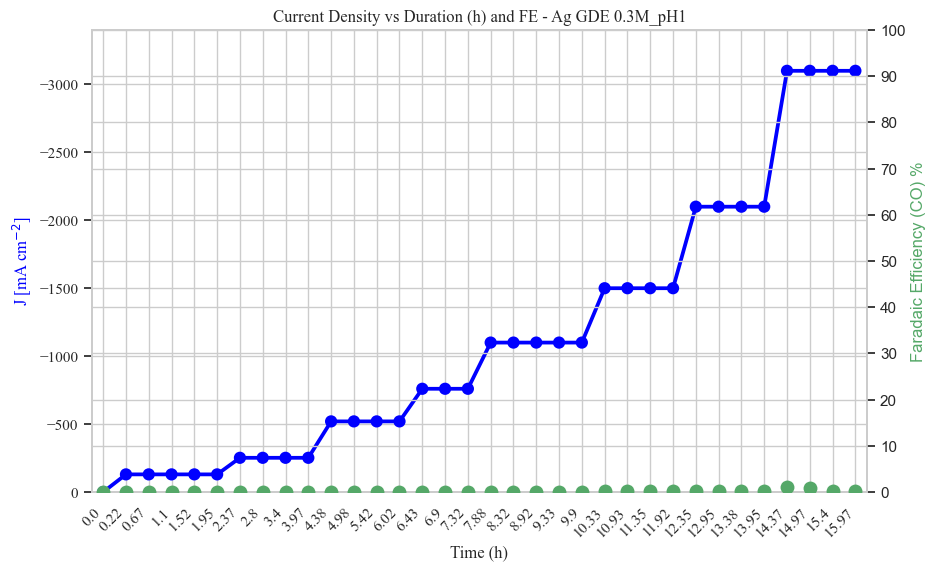

In [220]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=Book, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

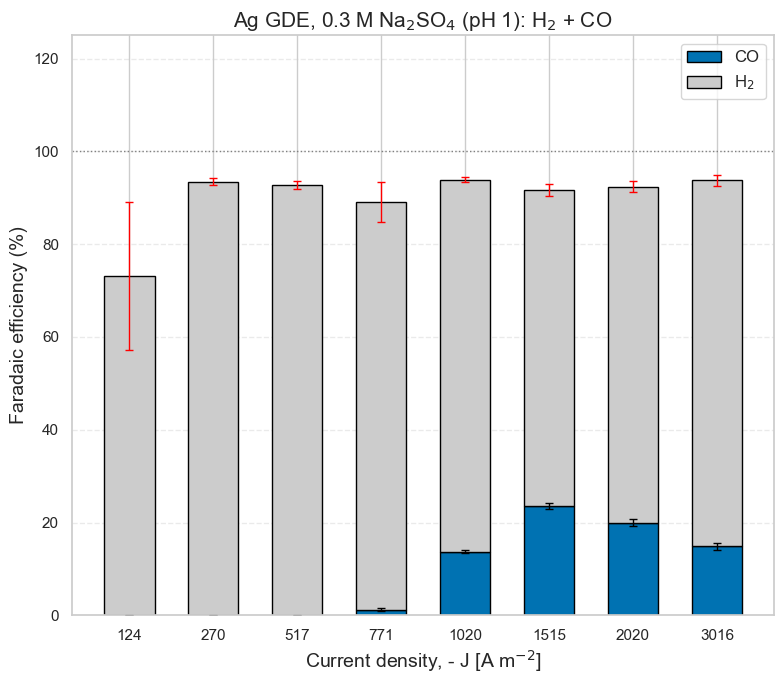

In [221]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M Na$_2$SO$_4$ (pH 1): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

The 130% you're seeing at 10 mA cm⁻² is the same low-current overshoot we've been discussing — let me explain why it lands specifically at the lowest current, and why it's expected rather than a bug.
First, a note on which number you're looking at. The grouped mean for that step is ~118%, but individual injections within the step scatter, and the highest one reaches ~130%. Both are the same phenomenon — the spread just shows up more in single points than in the average.
Now the mechanism. Faradaic efficiency is a ratio of two independently measured things:
FE(H₂) = (H₂ you detected) ÷ (charge you applied) = c(H2) · flow / V_m · 2F ÷ I
At 10 mA cm⁻² the denominator I is only 0.1 A — your smallest current by a factor of 30. That has two consequences that both push the ratio up:

A fixed measurement bias becomes huge in relative terms. The numerator carries a roughly constant offset — most likely the flow rate. In a gas-diffusion flow cell the Flow rate you used is very probably the CO₂ inlet flow, but FE needs the outlet flow. At high current the cell produces lots of gas, so a small flow error is a small fraction of a big number. At 0.1 A the cell makes almost no gas, so that same flow term dominates the H₂ calculation, and any overestimate in it is divided by a tiny current — inflating FE by 20–30%. This is exactly why the overshoot is largest at 10 and shrinks as you go up (118 → 107 → 98%).
Tiny signals are noisy. At 0.1 A the H₂ peak is small (area ~1–3 vs ~24 at high current), so GC integration noise, baseline, and not-quite-steady-state all matter more. Your error bar there is ±25%, far larger than at any other current — the data itself is telling you this point is the least precise.

There's also a real chemistry reason the true value sits right at the ceiling: at 0.1 A in pH 1, essentially all the current goes to hydrogen evolution (FE_H₂ genuinely ≈ 100%, CO ≈ 0). So the measured value is scattering around 100% — and when you scatter around a value that's already at the maximum, with a positive flow bias and large noise, you land above it. A point sitting at 130% is the noisy, slightly-biased measurement of something whose real value is ~100%.
What it is not: it's not the current-assignment problem (that one scrambled values across all currents, not just the lowest), and it's not something to fix by clipping. More than 100% is physically impossible as a true value, so it flags measurement uncertainty — which is honest information, not an error to hide.
For the publication, the clean way to handle it:

Keep the value as measured, with its error bar, and let it sit above the 100% line.
Check whether your Flow rate column is inlet or outlet flow — if it's inlet, switching to the outlet flow (or correcting for CO₂ consumption) is a legitimate fix that will pull the low-current points down toward 100%. That's correcting the input, not the output.
Add a sentence noting that low-current-density points carry the largest relative uncertainty because FE divides a small, near-detection-limit gas signal by a small applied charge.

## Median

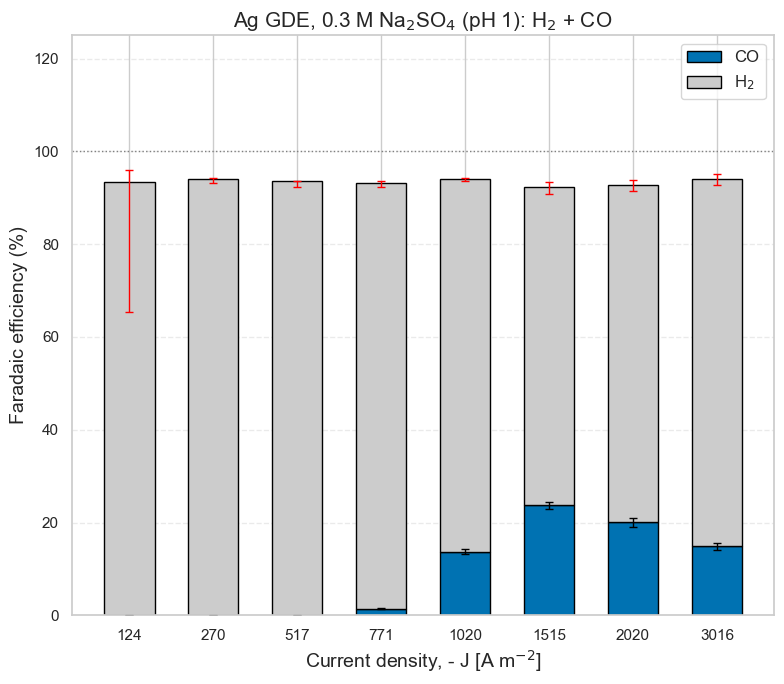

In [224]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(
    r"Ag GDE, 0.3 M Na$_2$SO$_4$ (pH 1): H$_2$ + CO",
    fontsize=15
)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [225]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [226]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,73.045689,0.000000,93.345938,0.000000,15.966087,0.000000,39.108766,0.000000,65.438069,...,0.016735,6,27.907869,2.650058,0.000000,0.000000,27.907869,2.650058,0–2,124
1,250,93.478799,0.000000,93.971158,0.000000,0.684385,0.000000,1.368769,0.000000,93.163724,...,0.032953,4,0.807434,0.315075,0.000000,0.000000,0.807434,0.315075,2–4,270
2,500,92.797633,0.000000,93.554912,0.000000,0.830273,0.000000,1.438075,0.000000,92.347040,...,0.059318,3,1.207872,0.071954,0.000000,0.000000,1.207872,0.071954,4–6,517
3,750,87.935941,1.187776,91.850038,1.400596,4.273079,0.303805,9.554894,0.679328,90.955864,...,0.082866,5,0.894174,0.421706,0.101814,0.172704,1.159779,0.152294,6–8,771
4,1000,80.140729,13.747350,80.199528,13.758281,0.563520,0.290039,1.127039,0.580078,79.755461,...,0.094152,4,0.444067,0.385268,0.499563,0.488632,0.705394,0.144600,8–10,1020
5,1500,68.147937,23.586037,68.390835,23.828212,1.317379,0.673867,2.634758,1.347734,66.899529,...,0.116840,4,1.491306,1.248408,0.928087,0.685912,0.805394,0.320321,10–12,1515
6,2000,72.377963,19.977600,72.604767,20.169879,1.156660,0.823006,2.313321,1.646013,71.312970,...,0.156943,4,1.291797,1.064994,1.064141,0.871862,0.425324,0.006242,12–14,2020
7,3000,78.839858,14.906535,79.191009,14.865801,1.171238,0.747357,2.342477,1.494713,77.833158,...,0.228712,4,1.357850,1.006699,0.719142,0.759876,0.597975,0.287558,14–16,3016


In [229]:
Res_Book
# Res_Book.to_csv('20240508_0.3M Na2SO4_pH1.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,73.045689,0.000000,93.345938,0.000000,15.966087,0.000000,39.108766,0.000000,65.438069,...,0.016735,6,27.907869,2.650058,0.000000,0.000000,27.907869,2.650058,0–2,124
1,250,93.478799,0.000000,93.971158,0.000000,0.684385,0.000000,1.368769,0.000000,93.163724,...,0.032953,4,0.807434,0.315075,0.000000,0.000000,0.807434,0.315075,2–4,270
2,500,92.797633,0.000000,93.554912,0.000000,0.830273,0.000000,1.438075,0.000000,92.347040,...,0.059318,3,1.207872,0.071954,0.000000,0.000000,1.207872,0.071954,4–6,517
3,750,87.935941,1.187776,91.850038,1.400596,4.273079,0.303805,9.554894,0.679328,90.955864,...,0.082866,5,0.894174,0.421706,0.101814,0.172704,1.159779,0.152294,6–8,771
4,1000,80.140729,13.747350,80.199528,13.758281,0.563520,0.290039,1.127039,0.580078,79.755461,...,0.094152,4,0.444067,0.385268,0.499563,0.488632,0.705394,0.144600,8–10,1020
5,1500,68.147937,23.586037,68.390835,23.828212,1.317379,0.673867,2.634758,1.347734,66.899529,...,0.116840,4,1.491306,1.248408,0.928087,0.685912,0.805394,0.320321,10–12,1515
6,2000,72.377963,19.977600,72.604767,20.169879,1.156660,0.823006,2.313321,1.646013,71.312970,...,0.156943,4,1.291797,1.064994,1.064141,0.871862,0.425324,0.006242,12–14,2020
7,3000,78.839858,14.906535,79.191009,14.865801,1.171238,0.747357,2.342477,1.494713,77.833158,...,0.228712,4,1.357850,1.006699,0.719142,0.759876,0.597975,0.287558,14–16,3016


## Mean and StD of FE(CO) through time

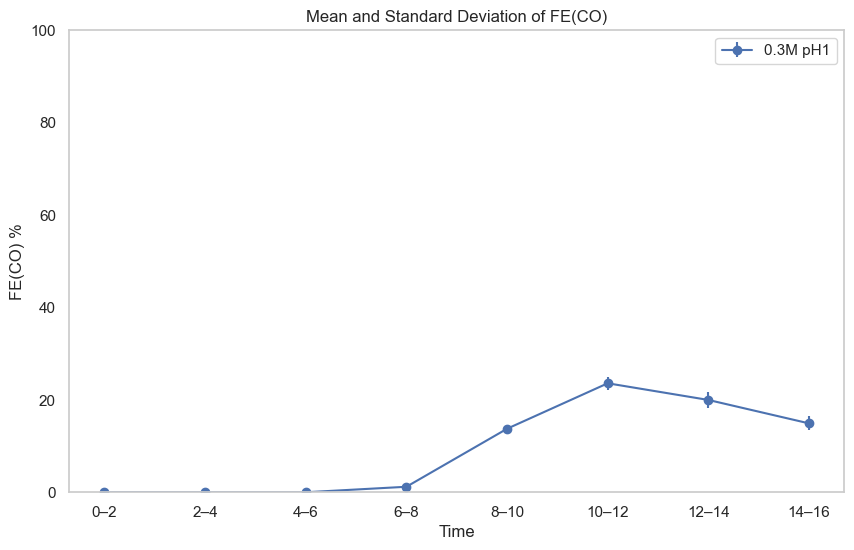

In [230]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M pH1')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240508_0.3M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

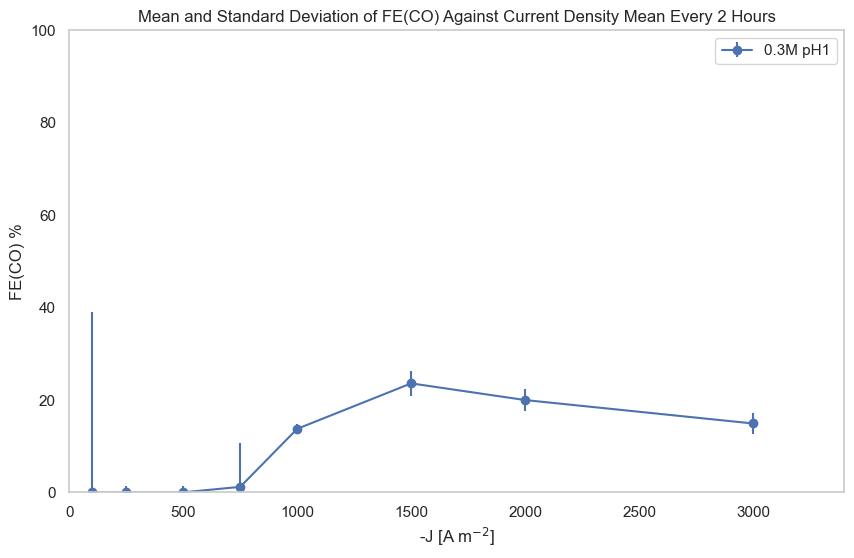

In [231]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(H2)_std'], fmt='-o', label='0.3M pH1')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240508_0.3M_pH1_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()

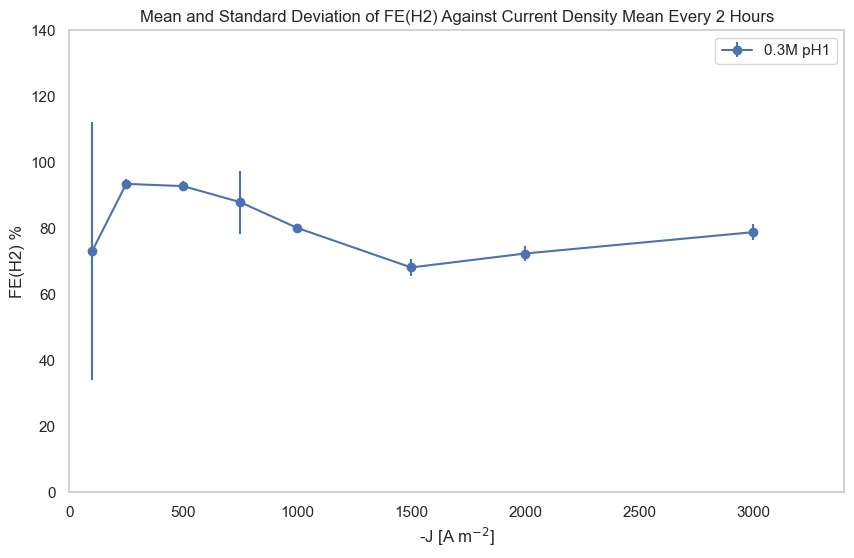

In [232]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(H2)_mean'], 
            yerr=Res_Book['FE(H2)_std'], fmt='-o', label='0.3M pH1')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(H2) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,140)
ax.set_title('Mean and Standard Deviation of FE(H2) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240508_0.3M_pH1_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()